In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score

# New Section

In [ ]:
df=pd.read_csv('diabetes.csv')

In [ ]:
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
df.shape

(768, 9)

In [ ]:
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
print(df[["Insulin","Glucose"]])

     Insulin  Glucose
0          0      148
1          0       85
2          0      183
3         94       89
4        168      137
..       ...      ...
763      180      101
764        0      122
765      112      121
766        0      126
767        0       93

[768 rows x 2 columns]


In [ ]:
print(df.iloc[0]) #first row

Pregnancies                   6.000
Glucose                     148.000
BloodPressure                72.000
SkinThickness                35.000
Insulin                       0.000
BMI                          33.600
DiabetesPedigreeFunction      0.627
Age                          50.000
Outcome                       1.000
Name: 0, dtype: float64


In [ ]:
print(df.iloc[5:10:2])#first two rows

   Pregnancies  Glucose  BloodPressure  SkinThickness  ...   BMI  DiabetesPedigreeFunction  Age  Outcome
5            5      116             74              0  ...  25.6                     0.201   30        0
7           10      115              0              0  ...  35.3                     0.134   29        0
9            8      125             96              0  ...   0.0                     0.232   54        1

[3 rows x 9 columns]


In [ ]:
print(df.loc[4,"Insulin"])#slicing indices of specific columns

168


In [ ]:
print(df.loc[0:5,"Insulin"])

0      0
1      0
2      0
3     94
4    168
5      0
Name: Insulin, dtype: int64


In [ ]:
print(df.loc[0:5,["Insulin","Glucose"]])

   Insulin  Glucose
0        0      148
1        0       85
2        0      183
3       94       89
4      168      137
5        0      116


In [ ]:
subset_age=df["Age"]>18 #boolean indexing
df[subset_age]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
#adding a column
df["gender"]=["female"]*768
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,gender
0,6,148,72,35,0,33.6,0.627,50,1,female
1,1,85,66,29,0,26.6,0.351,31,0,female
2,8,183,64,0,0,23.3,0.672,32,1,female
3,1,89,66,23,94,28.1,0.167,21,0,female
4,0,137,40,35,168,43.1,2.288,33,1,female


In [ ]:
#[df["gender"]=["female"]*400,df["male]"*368]

In [ ]:
for index, value in df["Pregnancies"].items(): #iterate through df["Pregnancies"] column
  if value>0: #if condition is satisfied
    df.loc[index, "gender"] = "female" #then gender would be female
  else:
    df.loc[index, "gender"] = "male" #else gender would be male

In [ ]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,gender
0,6,148,72,35,0,33.6,0.627,50,1,female
1,1,85,66,29,0,26.6,0.351,31,0,female
2,8,183,64,0,0,23.3,0.672,32,1,female
3,1,89,66,23,94,28.1,0.167,21,0,female
4,0,137,40,35,168,43.1,2.288,33,1,male
...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,female
764,2,122,70,27,0,36.8,0.340,27,0,female
765,5,121,72,23,112,26.2,0.245,30,0,female
766,1,126,60,0,0,30.1,0.349,47,1,female


In [ ]:
df["Age"] =df["Age"]+1 #updating

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,gender
0,6,148,72,35,0,33.6,0.627,51,1,female
1,1,85,66,29,0,26.6,0.351,32,0,female
2,8,183,64,0,0,23.3,0.672,33,1,female
3,1,89,66,23,94,28.1,0.167,22,0,female
4,0,137,40,35,168,43.1,2.288,34,1,male


In [ ]:
#renaming a column

df.rename(columns={"gender":"Gender"},inplace=True)

In [ ]:
df['Age'].value_counts().head()

,count
Age,
23,72
22,63
26,48
25,46
24,38


In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0
Gender,0


In [ ]:
df_grouped=df.groupby("Age").sum()
df_grouped

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Outcome,Gender
Age,,,,,,,,,
22,68,6824,4154,1219,4639,1752.5,27.331,5,femalefemalefemalefemalefemalemalefemalefemale...
23,112,7791,4588,1475,5363,2124.7,31.005,11,femalefemalefemalefemalemalefemalefemalefemale...
24,60,4240,2444,850,4485,1197.1,16.666,7,femalefemalefemalefemalemalefemalefemalefemale...
25,87,5423,2988,1193,4049,1498.2,18.104,8,femalefemalefemalefemalefemalefemalemalefemale...
26,85,5284,2864,1150,3979,1533.3,28.824,14,malefemalefemalefemalefemalemalefemalefemalefe...
27,65,3901,2118,781,2999,1152.2,13.644,8,femalefemalefemalefemalemalefemalefemalefemale...
28,82,3689,2352,588,2020,1022.4,15.096,8,femalefemalefemalefemalefemalefemalefemalemale...
29,106,4197,2391,827,3311,1177.5,16.087,10,femalefemalefemalefemalefemalefemalemalefemale...
30,96,3694,1979,609,2575,972.7,11.858,13,femalefemalefemalemalefemalefemalefemalefemale...


In [ ]:
df.sort_values("Age",ascending=False)



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Gender
459,9,134,74,33,60,25.9,0.460,82,0,female
453,2,119,0,0,0,19.6,0.832,73,0,female
666,4,145,82,18,0,32.5,0.235,71,1,female
123,5,132,80,0,0,26.8,0.186,70,0,female
684,5,136,82,0,0,0.0,0.640,70,0,female
...,...,...,...,...,...,...,...,...,...,...
240,1,91,64,24,0,29.2,0.192,22,0,female
136,0,100,70,26,50,30.8,0.597,22,0,male
382,1,109,60,8,182,25.4,0.947,22,0,female
392,1,131,64,14,415,23.7,0.389,22,0,female


In [ ]:
def age_category(age):
  if age<30:
    return "Young"
  elif age<50:
    return "Middle-aged"
  else:
    return "Old"
  age_category()

In [ ]:
df["Age_category"]=df["Age"].apply(age_category)

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Gender,Age_category
0,6,148,72,35,0,33.6,0.627,51,1,female,Old
1,1,85,66,29,0,26.6,0.351,32,0,female,Middle-aged
2,8,183,64,0,0,23.3,0.672,33,1,female,Middle-aged
3,1,89,66,23,94,28.1,0.167,22,0,female,Young
4,0,137,40,35,168,43.1,2.288,34,1,male,Middle-aged


In [ ]:
df.to_csv("diabetes_new.csv")

In [ ]:
df.to_json("diabetes_new.csv")

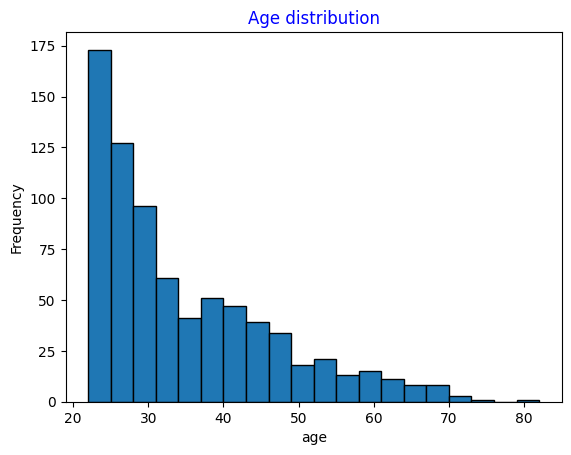

In [ ]:
plt.hist(df["Age"],bins=20,edgecolor="black")
plt.xlabel("age")
plt.ylabel("Frequency")
plt.title("Age distribution",color="blue")
plt.show()

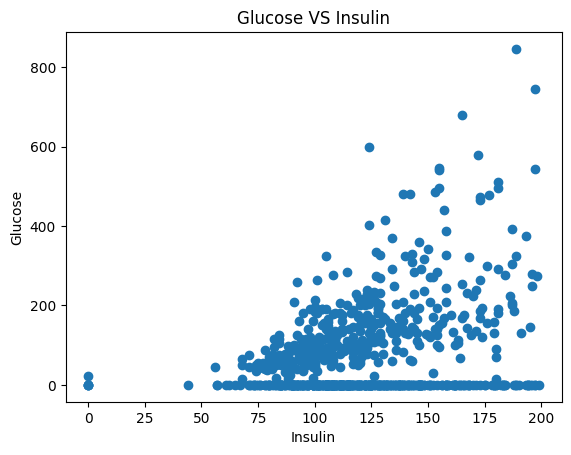

In [ ]:
plt.scatter(df["Glucose"],df["Insulin"],alpha=1)
plt.xlabel("Insulin")
plt.ylabel("Glucose")
plt.title("Glucose VS Insulin")
plt.show()

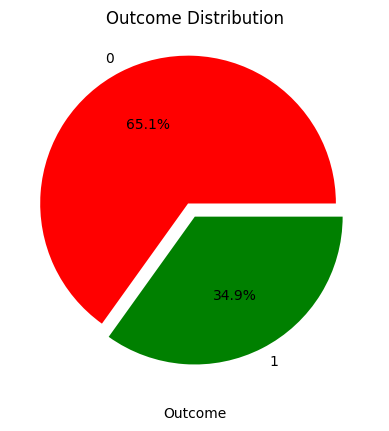

In [ ]:
colors=["red","green"]
outcome_counts=df["Outcome"].value_counts()
plt.pie(outcome_counts,labels=outcome_counts.index,autopct="%1.1f%%",colors=colors,explode=(0.1,0))
plt.xlabel("Outcome")
plt.title("Outcome Distribution")
plt.show()

In [ ]:
arr1=np.array([1,2,3,45,])# 1D array

In [ ]:
arr2=np.array([[1,2,3],[4,5,6]])

In [ ]:
arr2.shape

(2, 3)

In [ ]:
print (np.sum(arr2))
print(np.sum(arr2,axis=0))
print(np.sum(arr2,axis=1))

21
[5 7 9]
[ 6 15]


In [ ]:
arr1=np.array([1,2,3,4,5,])
print(arr1)

reshaped_arr=arr1.reshape(2,2)
print(reshaped_arr)


[ 1  2  3 45]
[[ 1  2]
 [ 3 45]]


In [ ]:
print(np.std(arr1))

18.632968094214082


In [ ]:
print(arr1.T)

[ 1  2  3 45]


In [ ]:
arr= np.arange(1,10)
print(arr)

[1 2 3 4 5 6 7 8 9]


In [ ]:
arr= np.arange(1,10).reshape(3,3)
print(arr)

[[1 2 3]
 [4 5 6]
 [7 8 9]]


In [ ]:
print(arr.T) #Transposing(switching rows to cols)

[[1 4 7]
 [2 5 8]
 [3 6 9]]


In [ ]:
print(arr[:])

[[1 2 3]
 [4 5 6]
 [7 8 9]]


In [ ]:
print(arr[1:2])

[[4 5 6]]


In [ ]:
#stacking
a=np.array([1,2,3])
b=np.array([4,5,6])
print(np.hstack((a,b))) #arranges them horizontally

[1 2 3 4 5 6]


In [ ]:
print(np.vstack((a,b))) #arranges them vertically

[[1 2 3]
 [4 5 6]]


In [ ]:
split_arr=np.split(arr,3)#split(only splits evenly)

In [ ]:
split_arr

[array([[1, 2, 3]]), array([[4, 5, 6]]), array([[7, 8, 9]])]